# **Imports**

In [ ]:
!pip install pmdarima
!pip install git+https://github.com/scikit-learn-contrib/py-earth@v0.2dev

     |████████████████████████████████| 1.5 MB 5.2 MB/s 
     |████████████████████████████████| 9.5 MB 51.8 MB/s 
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.10.2
    Uninstalling statsmodels-0.10.2:
      Successfully uninstalled statsmodels-0.10.2
  Cloning https://github.com/scikit-learn-contrib/py-earth (to revision v0.2dev) to /tmp/pip-req-build-cbsgasvh
  Running command git clone -q https://github.com/scikit-learn-contrib/py-earth /tmp/pip-req-build-cbsgasvh
  Running command git checkout -b v0.2dev --track origin/v0.2dev
  Switched to a new branch 'v0.2dev'
  Branch 'v0.2dev' set up to track remote branch 'v0.2dev' from 'origin'.
  Created wheel for sklearn-contrib-py-earth: filename=sklearn_contrib_py_earth-0.1.0+16.g400f84d-cp37-cp37m-linux_x86_64.whl size=3997322 sha256=1401d43c97053adbfd5f69f96fee6482c5704f5b329b6b7c17e11628004653b6
  Stored in directory: /tmp/pip-ephem-wheel-cache-yzflnn8r/wheels/79/d7/aa/1e418a9aea84424ef2ce2697ae7c

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import datetime
import warnings
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
import sklearn
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots  import plot_acf as pltacf
from  statsmodels.tsa.stattools import pacf as PACF
from statsmodels.graphics.tsaplots  import plot_pacf as pltpacf
from pmdarima.arima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')

In [ ]:
!gdown --id 13L_plstV8yrYpjynopRunNVpageRgIMN

Downloading...
From: https://drive.google.com/uc?id=13L_plstV8yrYpjynopRunNVpageRgIMN
To: /content/SUNPHARMA.NS.csv
100% 157k/157k [00:00<00:00, 45.3MB/s]


In [ ]:
stock_name="SUNPHARMA"

In [ ]:
df_stock = pd.read_csv('SUNPHARMA.NS.csv',index_col='Date')
df_stock.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,810.049988,817.900024,806.200012,815.549988,986728.0,4,1,1,7791.299805,11.700012
2016-01-04,813.900024,821.299988,795.099976,799.099976,2388588.0,0,4,1,7784.649902,26.200012
2016-01-05,807.000000,807.000000,792.049988,800.500000,1632394.0,1,5,1,7741.000000,14.950012
2016-01-06,805.000000,805.799988,790.750000,791.950012,2168214.0,2,6,1,7568.299805,15.049988
2016-01-07,788.000000,799.000000,778.650024,783.799988,2082334.0,3,7,1,7601.350098,20.349976


#**ARIMA - Autoregression Intergrated Moving Average**

##*Decomposing the data*

In [ ]:
df_stock['Close'].head()

Date
2016-01-01    815.549988
2016-01-04    799.099976
2016-01-05    800.500000
2016-01-06    791.950012
2016-01-07    783.799988
Name: Close, dtype: float64

Text(0.5, 1.0, 'Close Price - SUNPHARMA')

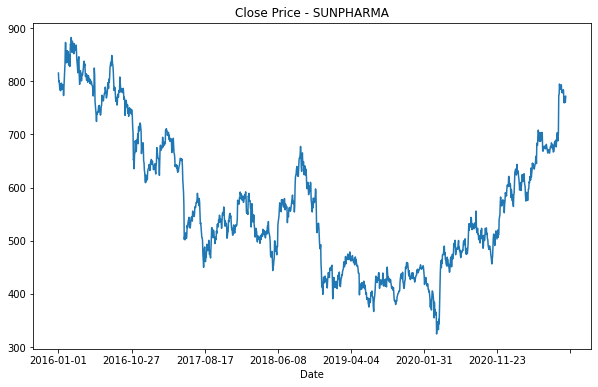

In [ ]:
plt.rcParams['figure.figsize'] = (10,6)
df_stock['Close'].plot()
plt.title("Close Price - "+stock_name)

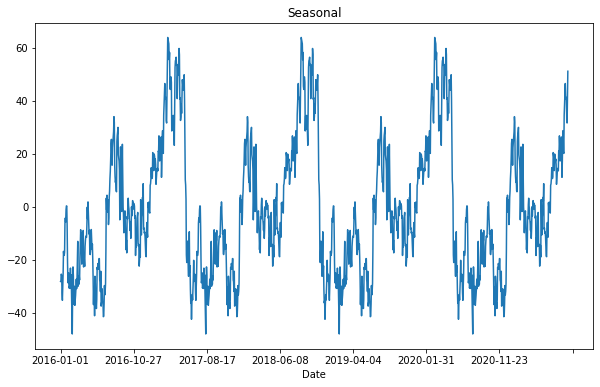

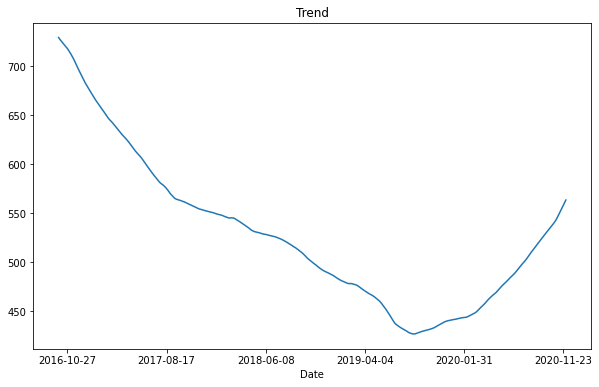

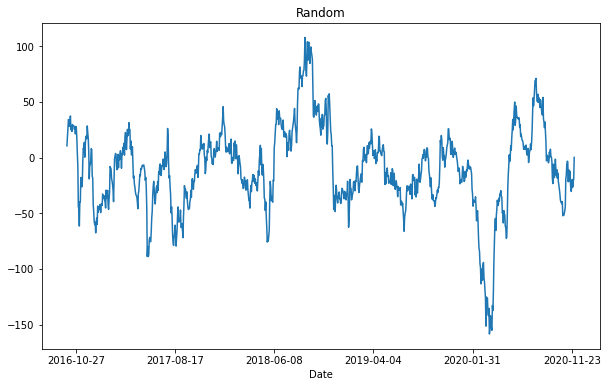

In [ ]:
plt.rcParams['figure.figsize'] = (10,6)
decomposition=seasonal_decompose(df_stock['Close'],freq=365)
decomposition.seasonal.plot()
plt.title("Seasonal")
plt.show()
decomposition.trend.plot()
plt.title("Trend")
plt.show()
decomposition.resid.plot()
plt.title("Random")
plt.show()

##*Stationary Check*

In [ ]:
Stationary=False
dvalue=0
Stationary_df=df_stock['Close'].copy()
while(Stationary==False):
  dftest = adfuller(Stationary_df.dropna(),autolag='AIC')
  dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
  for key,value in dftest[4].items():
    dfoutput['critical value (%s)'%key]= value
  print(dftest[1])
  if (dftest[1]>0.05):
    Stationary=False
    Stationary_df = Stationary_df - Stationary_df.shift(1)
  else :
    Stationary=True
  dvalue+=1  
print(dfoutput)
print("Differencing Value : ",dvalue)

0.38774182764648624
Test Statistic                   -1.785384
p-value                           0.387742
#lags used                        0.000000
number of observations used    1387.000000
critical value (1%)              -3.435073
critical value (5%)              -2.863626
critical value (10%)             -2.567881
dtype: float64
Differencing Value :  1


##*ACF*

In [ ]:
from  statsmodels.tsa.stattools import acf as ACF
ACFOutput = ACF(Stationary_df.dropna(),nlags=20)
print(ACFOutput)

[ 1.         -0.0029988  -0.02534337 -0.01794135  0.01997992 -0.00273466
 -0.0031445  -0.00234666  0.02800393 -0.00771645 -0.01023255 -0.03222846
 -0.01439643  0.01761484 -0.01660349  0.0101602  -0.00695907 -0.02117723
 -0.05171695  0.00434775  0.01279746]


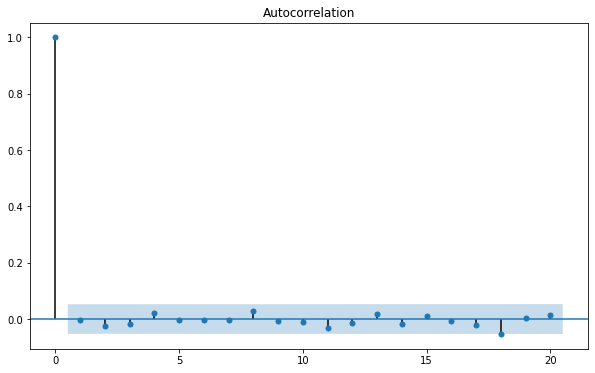

In [ ]:
plt.rcParams['figure.figsize'] = (10,6)
pltacf(Stationary_df.dropna(),lags=20)
plt.show()

##*PACF*

In [ ]:
PACFOutput = PACF(Stationary_df.dropna(),nlags=20)
print(PACFOutput)

[ 1.         -0.00300096 -0.0253892  -0.01814639  0.0192928  -0.00353508
 -0.00251674 -0.00182647  0.02754971 -0.00769368 -0.00895849 -0.03193093
 -0.01662605  0.01623388 -0.01817111  0.01176077 -0.00770447 -0.02213255
 -0.05171037  0.00380047  0.01030138]


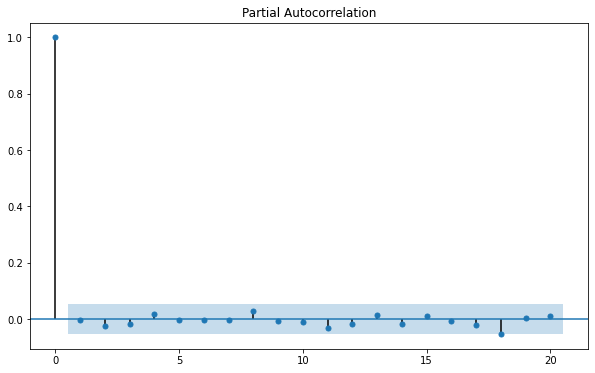

In [ ]:
plt.rcParams['figure.figsize'] = (10,6)
pltpacf(Stationary_df.dropna(),lags=20).show()
plt.show()

##*Test and Train Split*

In [ ]:
df_stock_train=df_stock.loc['2016-01-01':'2021-07-31']['Close']
df_stock_test=df_stock.loc['2021-07-31':]['Close']

In [ ]:
df_stock_train.tail()

Date
2021-07-26    703.400024
2021-07-27    688.299988
2021-07-28    687.799988
2021-07-29    703.000000
2021-07-30    773.950012
Name: Close, dtype: float64

In [ ]:
df_stock_test.head()

Date
2021-08-02    775.000000
2021-08-03    794.799988
2021-08-04    785.750000
2021-08-05    786.150024
2021-08-06    785.200012
Name: Close, dtype: float64

##*Model Fitting*

In [ ]:
arima_model=auto_arima(df_stock_train,seasonal=False,max_p=2,max_d=2,max_q=2,start_p=0,start_q=0,d=1)

In [ ]:
arima_model

ARIMA(maxiter=50, method='lbfgs', order=(0, 1, 0), out_of_sample_size=0,
      scoring='mse', scoring_args={}, seasonal_order=(0, 0, 0, 0),
      start_params=None, suppress_warnings=True, trend=None,
      with_intercept=False)

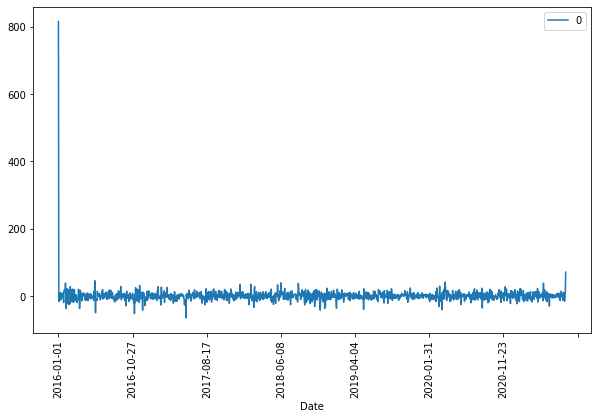

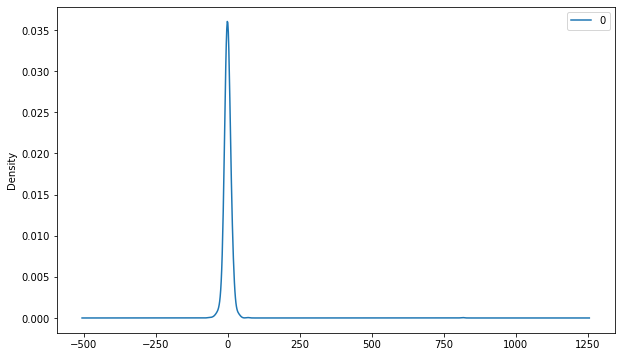

                 0
count  1369.000000
mean      0.565340
std      24.710264
min     -65.050018
25%      -6.299988
50%      -0.200012
75%       5.849976
max     815.549988


In [ ]:
model = ARIMA(df_stock_train, order=(0,1,0))
model_fit = model.fit()
residuals = pd.DataFrame(model_fit.resid)
plt.rcParams['figure.figsize'] = (10,6)
residuals.plot()
plt.xticks(rotation=90)
plt.show()
residuals.plot(kind='kde')
plt.show()
print(residuals.describe())

##*Forecasting and Testing*

In [ ]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values)):
    model = ARIMA(history, order=(0,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)
error = np.sqrt(mean_squared_error(df_stock_test.values, predictions))
print('Test Error Percentage',(error/np.mean(df_stock_test.values))*100)

Test Error Percentage 1.1585437126034457


([], <a list of 0 Text major ticklabel objects>)

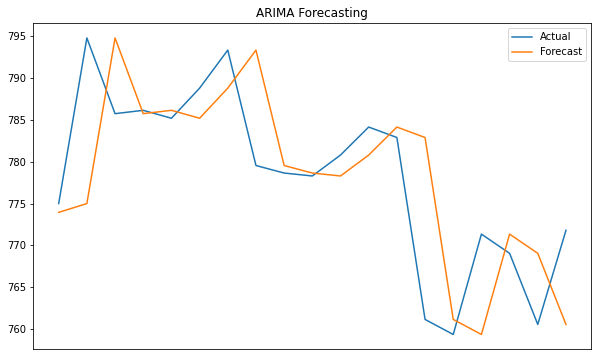

In [ ]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(df_stock_test, label='Actual')
plt.plot(predictions, label='Forecast')
plt.title('ARIMA Forecasting')
plt.legend()
plt.xticks([])

##*Forecast for August*

In [ ]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values[:14])):
    model = ARIMA(history, order=(0,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)

In [ ]:
predictions

[773.140853287741,
 774.2144455466643,
 794.1840073396351,
 784.9882749536607,
 785.4131809065703,
 784.4912634600369,
 788.1045294044699,
 792.6673739998397,
 778.9286182349283,
 778.0533364729878,
 777.7232790835747,
 780.2307903412211,
 783.583850426303,
 782.3571507599959]

#**MARS - Multivariate Adaptive Regression Splines**

In [ ]:
from pyearth import Earth

In [ ]:
df_stock_mars_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:5].copy()
df_stock_mars_test=df_stock.loc['2021-07-31':].iloc[:,:5].copy()

In [ ]:
df_stock_mars_train.shape

(1369, 5)

In [ ]:
df_stock_mars_test.shape

(19, 5)

In [ ]:
df_stock_mars_train.head()

,Open,High,Low,Close,Volume
Date,,,,,
2016-01-01,810.049988,817.900024,806.200012,815.549988,986728.0
2016-01-04,813.900024,821.299988,795.099976,799.099976,2388588.0
2016-01-05,807.000000,807.000000,792.049988,800.500000,1632394.0
2016-01-06,805.000000,805.799988,790.750000,791.950012,2168214.0
2016-01-07,788.000000,799.000000,778.650024,783.799988,2082334.0


In [ ]:
df_stock_mars_test

,Open,High,Low,Close,Volume
Date,,,,,
2021-08-02,785.000000,801.900024,764.099976,775.000000,18661462.0
2021-08-03,773.950012,804.349976,765.250000,794.799988,14678219.0
2021-08-04,791.000000,797.900024,779.700012,785.750000,5796169.0
2021-08-05,785.500000,794.400024,783.299988,786.150024,5026619.0
2021-08-06,786.500000,796.450012,781.549988,785.200012,4064324.0
2021-08-09,789.150024,793.000000,782.000000,788.799988,2873586.0
2021-08-10,789.950012,798.799988,782.200012,793.349976,5656020.0
2021-08-11,794.000000,795.000000,773.299988,779.549988,4275776.0
2021-08-12,780.000000,781.250000,773.150024,778.650024,2821380.0


In [ ]:
x_train_mars = df_stock_mars_train.drop(['Close'], axis=1)
y_train_mars = df_stock_mars_train['Close']
x_test_mars = df_stock_mars_test.drop(['Close'], axis=1)
y_test_mars = df_stock_mars_test['Close']

##*Fitting the model*

In [ ]:
MARS_model = Earth(max_terms = 600,max_degree=3)
MARS_model_fitted = MARS_model.fit(x_train_mars, y_train_mars)
y_pred_mars = MARS_model_fitted.predict(x_test_mars[:14])

##*Evaluating the model*

In [ ]:
MSE = mean_squared_error(y_test_mars[:14], y_pred_mars)
RMSE = np.sqrt(MSE)
RMSE_mean = (RMSE/np.mean(y_test_mars[:14]))*100
print("RMSE Score :", round(RMSE, 2))
print("RMSE/Mean", round(RMSE_mean,1))

RMSE Score : 4.33
RMSE/Mean 0.6


##*Plotting Forecast vs Actual* 

([], <a list of 0 Text major ticklabel objects>)

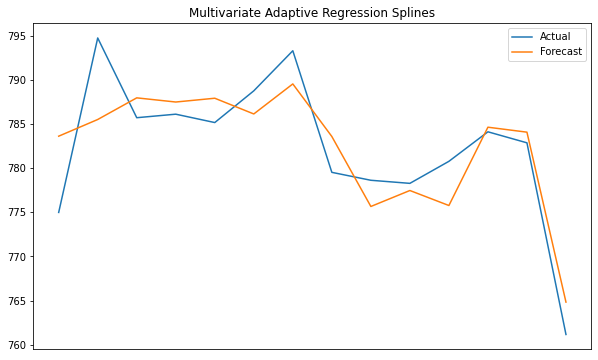

In [ ]:
plt.rcParams['figure.figsize'] = (10,6)
plt.plot(y_test_mars[:14], label='Actual')
plt.plot(y_pred_mars, label='Forecast')
plt.title('Multivariate Adaptive Regression Splines')
plt.legend()
plt.xticks([])

#**VAR - Vector Autoregression**

In [ ]:
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools.eval_measures import rmse, aic

In [ ]:
df_stock_var = df_stock.loc['2016-01-01':'2021-08-20'].iloc[:,:4].copy()
df_stock_var_train=df_stock.loc['2016-01-01':'2021-07-31'].iloc[:,:4].copy()
df_stock_var_test=df_stock.loc['2021-07-31':'2021-08-20'].iloc[:,:4].copy()


In [ ]:
df_stock_var_train.shape

(1369, 4)

In [ ]:
df_stock_var_test.shape

(14, 4)

In [ ]:
df_stock_var.shape

(1383, 4)

##*Plotting the Data*

In [1]:
fig, axes = plt.subplots(nrows=4, ncols=1, dpi=120, figsize=(10,6))
for i, ax in enumerate(axes.flatten()):
    data = df_stock_var[df_stock_var.columns[i]]
    ax.plot(data, linewidth=1)
    # Decorations
    ax.set_title(df_stock_var.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)

plt.tight_layout()

NameError: ignored

##*Granger Causality Test*

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag=12
test = 'ssr_chi2test'
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):    
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df

grangers_causation_matrix(df_stock_var, variables = df_stock_var.columns)        

,Open_x,High_x,Low_x,Close_x
Open_y,1.0000,0.0000,0.000,0.0
High_y,0.0000,1.0000,0.000,0.0
Low_y,0.0000,0.0000,1.000,0.0
Close_y,0.0312,0.0011,0.315,1.0


##*Cointegration Test*

In [ ]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

def cointegration_test(df_stock_var, alpha=0.05): 
    out = coint_johansen(df_stock_var,-1,5)
    d = {'0.90':0, '0.95':1, '0.99':2}
    traces = out.lr1
    cvts = out.cvt[:, d[str(1-alpha)]]
    def adjust(val, length= 6): return str(val).ljust(length)

    print('Name   ::  Test Statistic > C(95%)    =>   Significance  \n', '--'*20)
    for col, trace, cvt in zip(df_stock_var.columns, traces, cvts):
        print(adjust(col), ':: ', adjust(round(trace,2), 9), ">", adjust(cvt, 8), ' =>  ' , trace > cvt)

cointegration_test(df_stock_var)

Name   ::  Test Statistic > C(95%)    =>   Significance  
 ----------------------------------------
Open   ::  502.29    > 40.1749   =>   True
High   ::  258.06    > 24.2761   =>   True
Low    ::  86.79     > 12.3212   =>   True
Close  ::  0.2       > 4.1296    =>   False


##*ADF Test*

In [ ]:
def adfuller_test(series, signif=0.05, name='', verbose=False):
    """Perform ADFuller to test for Stationarity of given series and print report"""
    r = adfuller(series, autolag='AIC')
    output = {'test_statistic':round(r[0], 4), 'pvalue':round(r[1], 4), 'n_lags':round(r[2], 4), 'n_obs':r[3]}
    p_value = output['pvalue'] 
    def adjust(val, length= 6): return str(val).ljust(length)

    # Print Summary
    print(f'    Augmented Dickey-Fuller Test on "{name}"', "\n   ", '-'*47)
    print(f' Null Hypothesis: Data has unit root. Non-Stationary.')
    print(f' Significance Level    = {signif}')
    print(f' Test Statistic        = {output["test_statistic"]}')
    print(f' No. Lags Chosen       = {output["n_lags"]}')

    for key,val in r[4].items():
        print(f' Critical value {adjust(key)} = {round(val, 3)}')

    if p_value <= signif:
        print(f" => P-Value = {p_value}. Rejecting Null Hypothesis.")
        print(f" => Series is Stationary.")
    else:
        print(f" => P-Value = {p_value}. Weak evidence to reject the Null Hypothesis.")
        print(f" => Series is Non-Stationary.")    

In [ ]:
# ADF Test on each column
for name, column in df_stock_var_train.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -1.9827
 No. Lags Chosen       = 1
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.2942. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -1.6054
 No. Lags Chosen       = 2
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.4809. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit roo

##*ADF Test on first order differencing*

In [ ]:
df_differenced = df_stock_var_train.diff().dropna()

In [ ]:
# ADF Test on each column of 1st Differences Dataframe
for name, column in df_differenced.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "Open" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -40.5175
 No. Lags Chosen       = 0
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "High" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -25.3361
 No. Lags Chosen       = 1
 Critical value 1%     = -3.435
 Critical value 5%     = -2.864
 Critical value 10%    = -2.568
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "Low" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05

##*Selecting the number of lags*

In [ ]:
model = VAR(df_differenced)
x = model.select_order(maxlags=20)
x.summary()

,AIC,BIC,FPE,HQIC
0,16.78,16.79,1.936e+07,16.78
1,14.96,15.04,3.150e+06,14.99
2,14.51,14.64,1.994e+06,14.56
3,14.25,14.45,1.545e+06,14.33
4,14.18,14.44,1.438e+06,14.28
5,14.08,14.41*,1.307e+06,14.20
6,14.03,14.42,1.240e+06,14.18
7,13.99,14.44,1.189e+06,14.16*
8,13.98,14.49,1.184e+06,14.18
9,13.98,14.55,1.176e+06,14.19


##*Fitting the model*

In [ ]:
model_fitted = model.fit(14)
model_fitted.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 14, Sep, 2021
Time:                     14:48:02
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    14.8429
Nobs:                     1354.00    HQIC:                   14.2940
Log likelihood:          -16911.6    FPE:                1.16198e+06
AIC:                      13.9654    Det(Omega_mle):         985295.
--------------------------------------------------------------------
Results for equation Open
               coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------
const            -0.018363         0.134011           -0.137           0.891
L1.Open          -0.983858         0.038791          -25.363           0.000
L1.High           0.061084         0.037496            1.629           0.103


##*Durbin Watson Test*

In [ ]:
from statsmodels.stats.stattools import durbin_watson
out = durbin_watson(model_fitted.resid)

for col, val in zip(df_stock_var.columns, out):
    print(col, ':', round(val, 2))

Open : 2.01
High : 1.94
Low : 2.0
Close : 1.97


##*Getting the Forecast*

In [ ]:
# Get the lag order
lag_order = model_fitted.k_ar
print(lag_order)

# Input data for forecasting
forecast_input = df_differenced.values[-lag_order:]
forecast_input

14


array([[  2.09997559,   0.54998779,   2.20001221,   0.64996338],
       [  1.70001221,  16.5       ,   2.59997559,  14.45001221],
       [ 11.65002441,   3.05004883,  12.        ,   2.95001221],
       [  4.04998779,  -4.20001221,   0.29998779,  -2.95001221],
       [ -1.09997559,   7.45001221,   1.35003662,   5.59997559],
       [ -6.85003662,  -4.15002441,  -4.60003662,   0.65002441],
       [ 10.95001221,   0.09997559,  -4.14996338, -12.79998779],
       [ -9.        ,  -3.39996338,   1.64996338,  10.84997559],
       [  6.20001221,  10.75      ,   6.04998779,   6.70001221],
       [  9.        ,   6.04998779,  13.60003662,   9.40002441],
       [  9.79998779,   0.70001221, -21.35003662, -15.10003662],
       [-16.70001221, -13.75      ,  -1.29998779,  -0.5       ],
       [ -0.5       ,  14.        ,   8.15002441,  15.20001221],
       [ 15.15002441,  77.79998779,  15.45001221,  70.95001221]])

In [ ]:
nobs = 14
fc = model_fitted.forecast(y=forecast_input, steps=nobs)
df_forecast = pd.DataFrame(fc, index=df_stock_var.index[-nobs:], columns=df_stock_var.columns + '_1d')
df_forecast

,Open_1d,High_1d,Low_1d,Close_1d
Date,,,,
2021-08-02,74.631703,8.345543,60.785910,-2.779480
2021-08-03,-5.587749,-4.713384,-2.379695,-2.785877
2021-08-04,0.987900,3.992711,2.180547,7.738112
2021-08-05,2.402323,-2.540841,7.151147,0.852943
2021-08-06,1.149127,-0.665813,-4.637790,-3.873159
2021-08-09,-6.732674,-2.508489,-7.163359,-4.079490
2021-08-10,-1.669564,-1.560228,2.959929,1.331051
2021-08-11,3.239984,-0.934133,-2.428122,-2.262858
2021-08-12,-3.408072,-0.184025,0.616127,3.354058


##*Inverting forecast back to original scale*

In [ ]:
def invert_transformation(df_train, df_forecast, first_diff=False):
    """Revert back the differencing to get the forecast to original scale."""
    df_fc = df_forecast.copy()
    columns = df_train.columns
    for col in columns:        
        if first_diff:
          # Roll back 1st Diff
          df_fc[str(col)+'_forecast'] = df_train[col].iloc[-1] + df_fc[str(col)+'_1d'].cumsum()
    return df_fc

In [ ]:
df_results = invert_transformation(df_stock_var_train, df_forecast, first_diff=True)        
df_results.loc[:, ['Open_forecast','High_forecast','Low_forecast','Close_forecast']]

,Open_forecast,High_forecast,Low_forecast,Close_forecast
Date,,,,
2021-08-02,777.581715,792.095543,756.935935,771.170532
2021-08-03,771.993966,787.382159,754.556240,768.384655
2021-08-04,772.981866,791.374870,756.736787,776.122767
2021-08-05,775.384189,788.834030,763.887934,776.975709
2021-08-06,776.533316,788.168217,759.250144,773.102551
2021-08-09,769.800641,785.659728,752.086785,769.023061
2021-08-10,768.131078,784.099500,755.046714,770.354111
2021-08-11,771.371062,783.165367,752.618592,768.091254
2021-08-12,767.962990,782.981343,753.234719,771.445311


##*Plotting Forecast vs Actual*

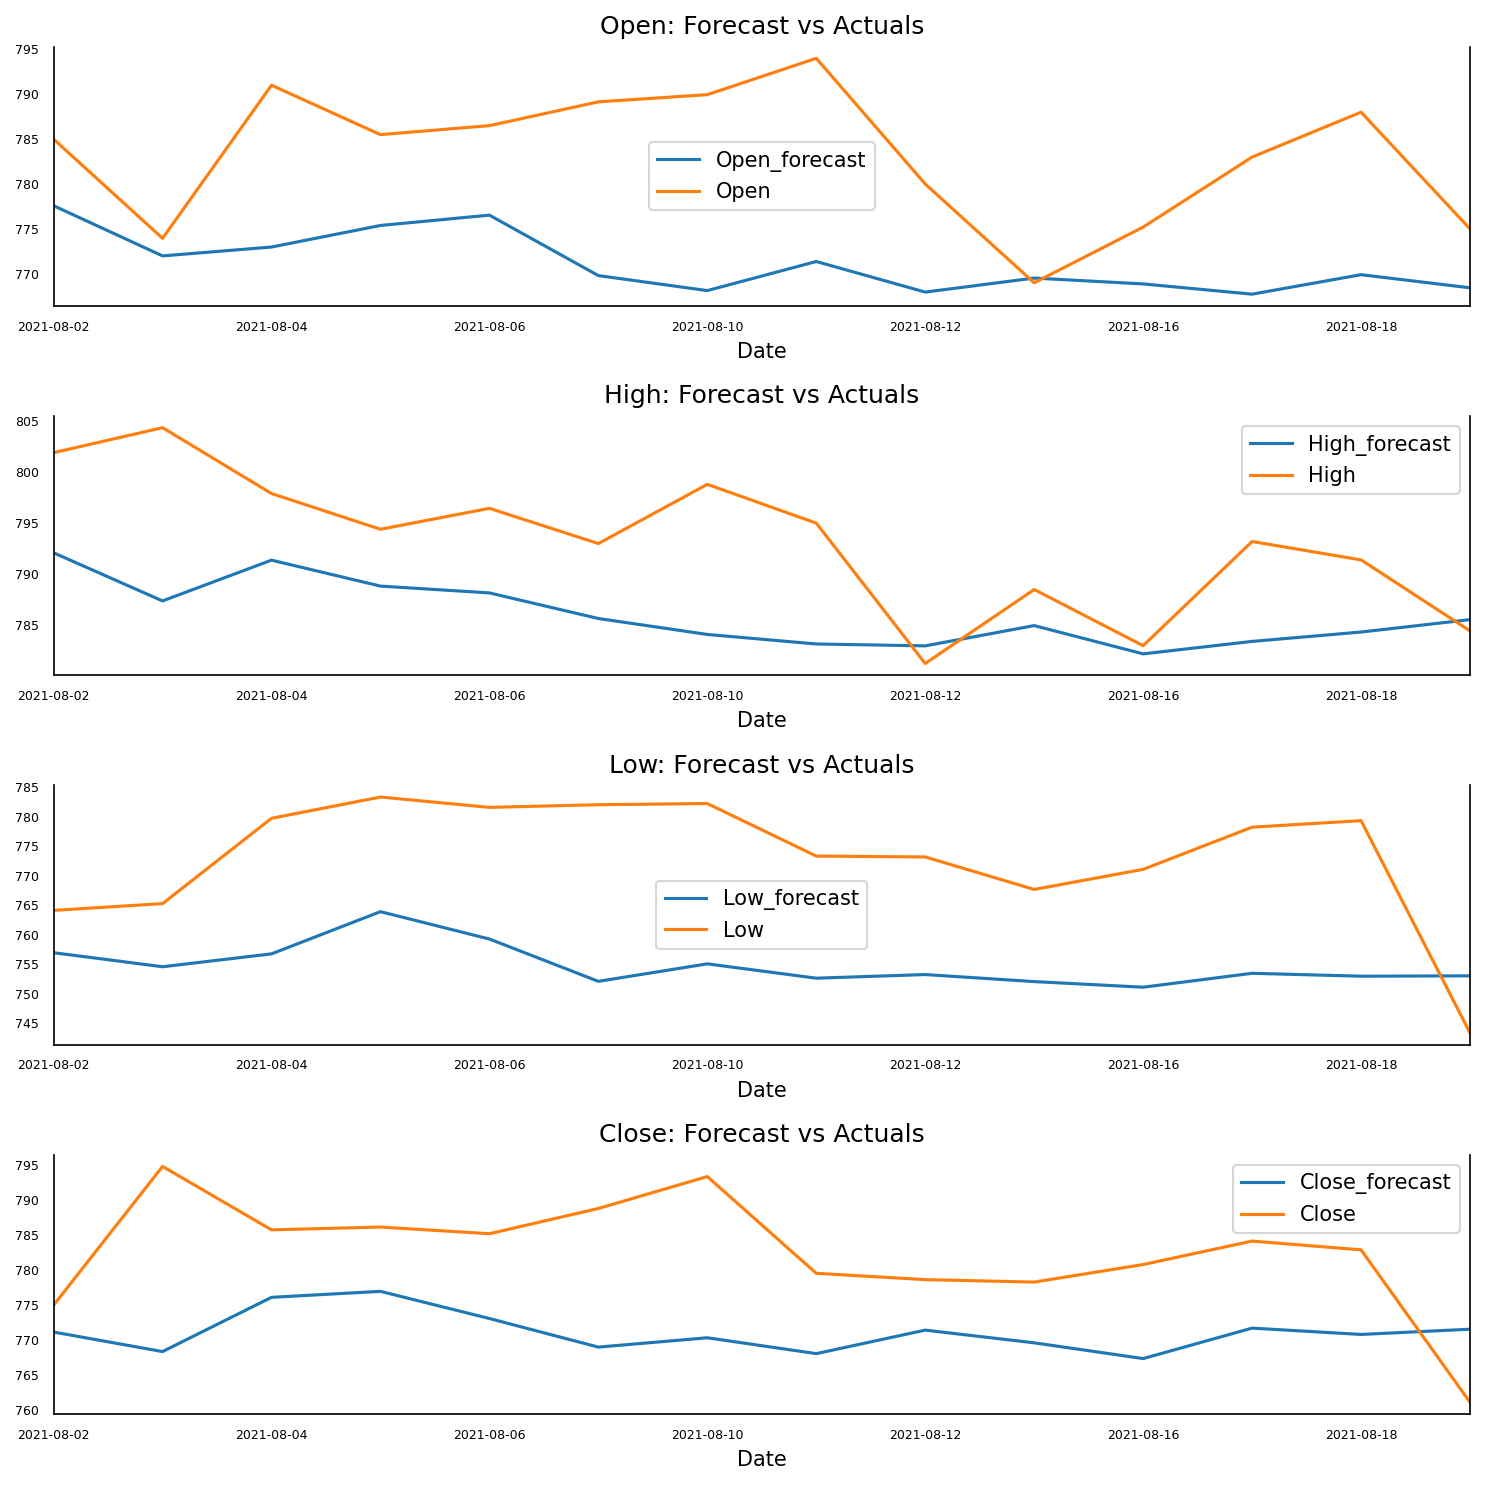

In [ ]:
 fig, axes = plt.subplots(nrows=4, ncols=1, dpi=150, figsize=(10,10))
 for i, (col,ax) in enumerate(zip(df_stock_var.columns, axes.flatten())):
   df_results[col+'_forecast'].plot(legend=True, ax=ax).autoscale(axis='x',tight=True)
   df_stock_var_test[col][-nobs:].plot(legend=True, ax=ax);
   ax.set_title(col + ": Forecast vs Actuals")
   ax.xaxis.set_ticks_position('none')
   ax.yaxis.set_ticks_position('none')
   ax.spines["top"].set_alpha(0)
   ax.tick_params(labelsize=6)

plt.tight_layout();

##*Evaluating the model*

In [ ]:
from statsmodels.tsa.stattools import acf
def forecast_accuracy(forecast, actual): 
    rmse = np.mean((forecast - actual)**2)**.5  
    rmse_p = (rmse/np.mean(actual))*100
    return({'rmse':rmse,'rmse_mean':rmse_p})

print('Forecast Accuracy of Open')
accuracy_prod = forecast_accuracy(df_results['Open_forecast'].values, df_stock_var_test['Open'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of High')
accuracy_prod = forecast_accuracy(df_results['High_forecast'].values, df_stock_var_test['High'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Low')
accuracy_prod = forecast_accuracy(df_results['Low_forecast'].values, df_stock_var_test['Low'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))

print('\nForecast Accuracy of Close')
accuracy_prod = forecast_accuracy(df_results['Close_forecast'].values, df_stock_var_test['Close'])
for k, v in accuracy_prod.items():
    print(k, ': ', round(v,4))



Forecast Accuracy of Open
rmse :  13.9809
rmse_mean :  1.785

Forecast Accuracy of High
rmse :  8.8607
rmse_mean :  1.1172

Forecast Accuracy of Low
rmse :  20.8148
rmse_mean :  2.6922

Forecast Accuracy of Close
rmse :  14.1482
rmse_mean :  1.8081


#**Linear Regression**

In [ ]:
df_stock_train_lin=df_stock.loc['2016-01-01':'2021-07-31'].copy()
df_stock_test_lin=df_stock.loc['2021-07-31':].copy()


##*Normalize the data*

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()
df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.fit_transform(df_stock_train_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])
df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.transform(df_stock_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])

In [ ]:
df_stock_train_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,0.866957,0.854721,0.887094,815.549988,0.008332,4,1,1,0.091661,0.086493
2016-01-04,0.873791,0.860853,0.867169,799.099976,0.025302,0,4,1,0.090919,0.241324
2016-01-05,0.861543,0.835062,0.861695,800.500000,0.016148,1,5,1,0.086044,0.121196
2016-01-06,0.857992,0.832897,0.859361,791.950012,0.022635,2,6,1,0.066755,0.122264
2016-01-07,0.827816,0.820633,0.837641,783.799988,0.021595,3,7,1,0.070447,0.178857


In [ ]:
df_stock_test_lin.head()

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2021-08-02,0.822490,0.825863,0.811524,775.000000,0.222292,0,2,8,1.023069,0.365190
2021-08-03,0.802876,0.830282,0.813588,794.799988,0.174073,1,3,8,1.037370,0.379071
2021-08-04,0.833141,0.818649,0.839526,785.750000,0.066552,2,4,8,1.041369,0.155900
2021-08-05,0.823378,0.812337,0.845988,786.150024,0.057237,3,5,8,1.035070,0.080086
2021-08-06,0.825153,0.816034,0.842847,785.200012,0.045588,4,6,8,1.037309,0.120663


##*Checking for multicollinearity*

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor    

def calculate_vif_(X, thresh=10,verbose=True):
    cols = X.columns
    variables = np.arange(X.shape[1])
    dropped=True
    while dropped:
        dropped=False
        c = X[cols[variables]].values
        vif = [variance_inflation_factor(c, ix) for ix in np.arange(c.shape[1])]
        

        maxloc = vif.index(max(vif))
        if max(vif) > thresh:
            if verbose == True:
                print('dropping \'' + X[cols[variables]].columns[maxloc] + '\' at index: ' + str(maxloc))
            variables = np.delete(variables, maxloc)
            dropped=True
    if verbose == True:
        print('Remaining variables:')
        print(X.columns[variables])
    return X[cols[variables]]

##*Model Generation*

In [ ]:
def forward_regression(X, y,
                       threshold_in,
                       verbose=False):
    initial_list = []
    included = list(initial_list)
    while True:
        changed=False
        excluded = list(set(X.columns)-set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included+[new_column]]))).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed=True
            if verbose:
                print('Add  {:30} with p-value {:.6}'.format(best_feature, best_pval))

        if not changed:
            break

    return included

In [ ]:
def backward_regression(X, y,
                           threshold_out,
                           verbose=False):
    included=list(X.columns)
    while True:
        changed=False
        model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included]))).fit()
        pvalues = model.pvalues.iloc[1:]
        worst_pval = pvalues.max() 
        if worst_pval > threshold_out:
            changed=True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print('Drop {:30} with p-value {:.6}'.format(worst_feature, worst_pval))
        if not changed:
            break
    return included

In [ ]:
def model_generator(df_train,df_test):
    train_dummy=pd.get_dummies(df_train,columns=['Day of Week','Day of Month','Month'])
    test_dummy = pd.get_dummies(df_test,columns=['Day of Week','Day of Month','Month'])
    for i in [1,2,3,4,5,6,7,9,10,11,12]:
        test_dummy['Month_'+str(i)] = 0
        test_dummy['Month_'+str(i)] = test_dummy['Month_'+str(i)].astype('uint8')
    for i in range(1,32):
      if (i not in df_test['Day of Month'].unique()):
        test_dummy['Day of Month_'+str(i)] = 0
        test_dummy['Day of Month_'+str(i)] = test_dummy['Day of Month_'+str(i)].astype('uint8')   
    X=train_dummy.drop('Close',axis=1)
    y=train_dummy["Close"]
    X_f=calculate_vif_(X.select_dtypes(exclude='uint8'),10,False)
    X_f=pd.concat([X_f,X.iloc[:,6:]],axis=1)
    model=sm.OLS(y,X_f[backward_regression(X_f,y,0.01)],axis=1).fit()
    pred=model.predict(test_dummy[backward_regression(X_f,y,0.01)])
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(test_dummy['Close'], pred))
    rmse_pct= (rmse/np.mean(test_dummy['Close']))*100
    sig_var = model.pvalues.index.tolist()
    return model,sig_var,rmse_pct    

In [ ]:
 model,variables,rmse_per = model_generator(df_stock_train_lin,df_stock_test_lin)

In [ ]:
print(model.summary2())

                  Results: Ordinary least squares
Model:               OLS              Adj. R-squared:     0.998    
Dependent Variable:  Close            AIC:                8558.6303
Date:                2021-09-14 15:27 BIC:                8809.2785
No. Observations:    1369             Log-Likelihood:     -4231.3  
Df Model:            47               F-statistic:        1.622e+04
Df Residuals:        1321             Prob (F-statistic): 0.00     
R-squared:           0.998            Scale:              29.354   
-------------------------------------------------------------------
                 Coef.   Std.Err.    t     P>|t|   [0.025   0.975] 
-------------------------------------------------------------------
High            553.6369   0.6469 855.7805 0.0000 552.3677 554.9060
Range           -40.3435   1.6217 -24.8777 0.0000 -43.5248 -37.1621
Day of Week_0   215.7251   0.3746 575.8248 0.0000 214.9902 216.4601
Day of Week_1   215.9769   0.3690 585.2857 0.0000 215.2530 216.700

In [ ]:
print("Significance Variables :",'\n',*variables,sep='\n')

Significance Variables :


High
Range
Day of Week_0
Day of Week_1
Day of Week_2
Day of Week_3
Day of Week_4
Day of Month_1
Day of Month_2
Day of Month_3
Day of Month_4
Day of Month_5
Day of Month_6
Day of Month_7
Day of Month_8
Day of Month_9
Day of Month_10
Day of Month_11
Day of Month_12
Day of Month_13
Day of Month_14
Day of Month_15
Day of Month_16
Day of Month_17
Day of Month_18
Day of Month_19
Day of Month_20
Day of Month_21
Day of Month_22
Day of Month_23
Day of Month_24
Day of Month_25
Day of Month_26
Day of Month_27
Day of Month_28
Day of Month_29
Day of Month_30
Day of Month_31
Month_1
Month_2
Month_3
Month_4
Month_5
Month_6
Month_7
Month_8
Month_9
Month_10
Month_11
Month_12


In [ ]:
print("RMSE Percentage",rmse_per,sep='\n')

RMSE Percentage
0.5033741107632096


##*Univariate Forecasting with ARIMA for Linear Regression*

In [ ]:
print("Forecasting Variables :",'\n',list(set(variables) & set(list(df_stock.columns))),sep='\n')

Forecasting Variables :


['Range', 'High']


In [ ]:
df_stock_for_test_lin=df_stock_test_lin.iloc[:14].copy()
dummy_df = pd.DataFrame(index=df_stock_for_test_lin.index)

In [ ]:
df_stock

,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2016-01-01,810.049988,817.900024,806.200012,815.549988,986728.0,4,1,1,7791.299805,11.700012
2016-01-04,813.900024,821.299988,795.099976,799.099976,2388588.0,0,4,1,7784.649902,26.200012
2016-01-05,807.000000,807.000000,792.049988,800.500000,1632394.0,1,5,1,7741.000000,14.950012
2016-01-06,805.000000,805.799988,790.750000,791.950012,2168214.0,2,6,1,7568.299805,15.049988
2016-01-07,788.000000,799.000000,778.650024,783.799988,2082334.0,3,7,1,7601.350098,20.349976
...,...,...,...,...,...,...,...,...,...,...
2021-08-23,765.000000,770.000000,750.799988,759.349976,2375417.0,0,23,8,16624.599609,19.200012
2021-08-24,759.799988,777.950012,754.250000,771.349976,2732537.0,1,24,8,16634.650391,23.700012
2021-08-25,770.000000,776.000000,759.599976,769.049988,2254852.0,2,25,8,16636.900391,16.400024


In [ ]:
Stationary=False
dvalue=0
Stationary_df=df_stock['Low'].copy()
while(Stationary==False):
  dftest = adfuller(Stationary_df.dropna(),autolag='AIC')
  dfoutput=pd.Series(dftest[0:4],index=['Test Statistic','p-value','#lags used','number of observations used'])
  for key,value in dftest[4].items():
    dfoutput['critical value (%s)'%key]= value
  print(round(dftest[1]))
  if (dftest[1]>0.05):
    Stationary=False
    Stationary_df = Stationary_df - Stationary_df.shift(1)
  else :
    Stationary=True
  dvalue+=1  
print("Differencing Value : ",dvalue)

0
0
Differencing Value :  2


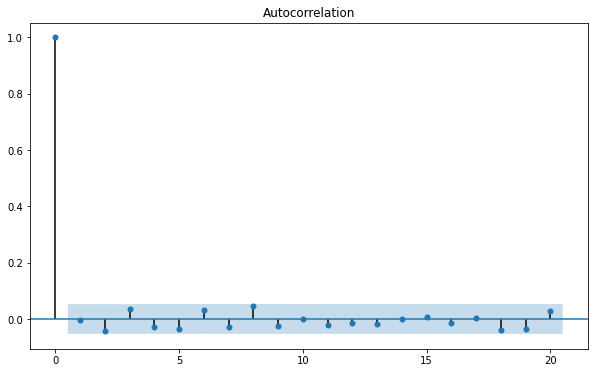

In [ ]:
pltacf(Stationary_df.dropna(),lags=20).show()
plt.show()

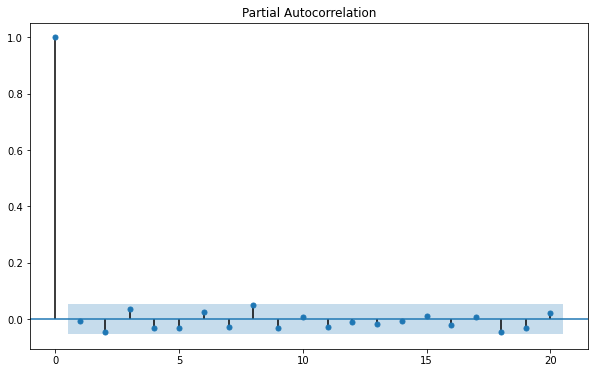

In [ ]:
pltpacf(Stationary_df.dropna(),lags=20).show()
plt.show()

In [ ]:
df_stock_train=df_stock.loc['2016-01-01':'2021-07-31']['Low']
df_stock_test=df_stock.loc['2021-07-31':]['Low']

In [ ]:
df_stock_test

Date
2021-08-02    764.099976
2021-08-03    765.250000
2021-08-04    779.700012
2021-08-05    783.299988
2021-08-06    781.549988
2021-08-09    782.000000
2021-08-10    782.200012
2021-08-11    773.299988
2021-08-12    773.150024
2021-08-13    767.650024
2021-08-16    771.049988
2021-08-17    778.200012
2021-08-18    779.299988
2021-08-20    743.349976
2021-08-23    750.799988
2021-08-24    754.250000
2021-08-25    759.599976
2021-08-26    759.250000
2021-08-27    758.099976
Name: Low, dtype: float64

In [ ]:
history = [x for x in df_stock_train.values]
predictions = list()
for t in range(len(df_stock_test.values[:14])):
    model = ARIMA(history, order=(0,2,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = df_stock_test.values[t]
    history.append(obs)

In [ ]:
predictions

[711.6000366210949,
 832.0499267577915,
 766.4000244140625,
 794.1500244140626,
 786.8999633789051,
 779.7999877929674,
 782.4500122070318,
 782.4000244140624,
 764.3999633789035,
 773.0000610351556,
 762.1500244140647,
 774.4499511718756,
 785.3500366210935,
 780.3999633789055]

In [ ]:
dummy_df['Low'] = predictions.copy()
dummy_df

,Low,High
Date,,
2021-08-02,711.600037,794.692140
2021-08-03,832.049927,800.367594
2021-08-04,766.400024,806.504859
2021-08-05,794.150024,796.734928
2021-08-06,786.899963,795.202650
2021-08-09,779.799988,797.155501
2021-08-10,782.450012,792.918497
2021-08-11,782.400024,800.534536
2021-08-12,764.399963,794.372805


In [ ]:
dummy_df['Range'] = dummy_df['High']-dummy_df['Low']
dummy_df.drop(columns=['Low'],inplace=True)

In [ ]:
dummy_df

,High,Range
Date,,
2021-08-02,794.692140,83.092103
2021-08-03,800.367594,-31.682333
2021-08-04,806.504859,40.104835
2021-08-05,796.734928,2.584904
2021-08-06,795.202650,8.302687
2021-08-09,797.155501,17.355513
2021-08-10,792.918497,10.468485
2021-08-11,800.534536,18.134512
2021-08-12,794.372805,29.972842


In [ ]:
df_stock_for_test_lin[list(set(variables) & set(list(df_stock.columns)))] = dummy_df[list(set(variables) & set(list(df_stock.columns)))].copy()

In [ ]:
print("Forecasted predictors test data")
df_stock_for_test_lin.head()

Forecasted predictors test data


,Open,High,Low,Close,Volume,Day of Week,Day of Month,Month,NIFTY50,Range
Date,,,,,,,,,,
2021-08-02,-0.569499,794.692140,-0.558586,775.000000,-0.003612,0,2,8,-0.778411,83.092103
2021-08-03,-0.569534,800.367594,-0.558583,794.799988,-0.003612,1,3,8,-0.778409,-31.682333
2021-08-04,-0.569481,806.504859,-0.558536,785.750000,-0.003612,2,4,8,-0.778409,40.104835
2021-08-05,-0.569498,796.734928,-0.558525,786.150024,-0.003612,3,5,8,-0.778409,2.584904
2021-08-06,-0.569495,795.202650,-0.558530,785.200012,-0.003612,4,6,8,-0.778409,8.302687


In [ ]:
df_stock_for_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']] = scaler.transform(df_stock_for_test_lin[['Open', 'High','Low','Volume','NIFTY50','Range']])

In [ ]:
model_for,variables_for,rmse_per_for = model_generator(df_stock_train_lin,df_stock_for_test_lin)

In [ ]:
print(model_for.summary2())

                  Results: Ordinary least squares
Model:               OLS              Adj. R-squared:     0.998    
Dependent Variable:  Close            AIC:                8558.6303
Date:                2021-09-14 15:33 BIC:                8809.2785
No. Observations:    1369             Log-Likelihood:     -4231.3  
Df Model:            47               F-statistic:        1.622e+04
Df Residuals:        1321             Prob (F-statistic): 0.00     
R-squared:           0.998            Scale:              29.354   
-------------------------------------------------------------------
                 Coef.   Std.Err.    t     P>|t|   [0.025   0.975] 
-------------------------------------------------------------------
High            553.6369   0.6469 855.7805 0.0000 552.3677 554.9060
Range           -40.3435   1.6217 -24.8777 0.0000 -43.5248 -37.1621
Day of Week_0   215.7251   0.3746 575.8248 0.0000 214.9902 216.4601
Day of Week_1   215.9769   0.3690 585.2857 0.0000 215.2530 216.700

In [ ]:
print("RMSE Percentage for forecasted predictors",rmse_per_for,sep='\n')

RMSE Percentage for forecasted predictors
1.3902080133248729
